**Komentarze do kodu znajdują się w kodzie i pod kodem**

In [55]:
# ładowanie odpowiednich modułów i funkcji
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
import tensorflow.keras.layers as layers
from tensorflow.keras.optimizers import Adam
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
import albumentations as A
import cv2
from tensorflow.keras.utils import Sequence
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, ReLU
from tensorflow.keras.models import Sequential

In [56]:
train, test = tf.keras.datasets.fashion_mnist.load_data()

# wydobycie obrazów oraz labelek
images, labels = train

# normalizacja wartości pikseli (maks. wartość
# wynosi 255.0, czyli aby znormalizować nasze dane,
# musimy podzielić każdy piksel przez maks. wartość)
images = images/255.0

# zapisujemy dane jako int
labels = labels.astype(np.int32)

In [57]:
# podzielenie danych na treningowe i testowe
X_train, X_test, y_train, y_test = \
    train_test_split(images, labels, test_size=0.1, random_state=10, stratify=labels)

# stworzenie zbioru typu Dataset z naszej listy
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))

# ustawienie batch_size na 32 oraz przetasowanie na bazie 1000 próbek
train_ds = train_ds.shuffle(1000).batch(32)

In [58]:
# stworzenie modelu sieci neuronowej
f_mnist_model = tf.keras.Sequential([
    # spłaszczanie obrazka do wektora jednowymiarowego
    layers.Flatten(input_shape=[28, 28]),

    layers.Dense(300, activation='relu'),

    # ostatnia warstwa posiada tyle neuronów ile mamy klas
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [59]:
# podsumowanie modelu
f_mnist_model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_16 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 10)             │         3,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 238,510 (931.68 KB)

 Trainable params: 238,510 (931.68 KB)

 Non-trainable params: 0 (0.00 B)

In [60]:
# kompilacja modelu
f_mnist_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

In [61]:
# trenowanie modelu, dokładność > 94 jest do osiągnięcia po około 22 epokach
train_stats = f_mnist_model.fit(train_ds, epochs=22, verbose=1)

Epoch 1/22
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.7848 - loss: 0.6123
Epoch 2/22
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8592 - loss: 0.3909
Epoch 3/22
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8731 - loss: 0.3449
Epoch 4/22
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8826 - loss: 0.3180
Epoch 5/22
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8906 - loss: 0.2973
Epoch 6/22
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8950 - loss: 0.2847
Epoch 7/22
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8997 - loss: 0.2686
Epoch 8/22
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - accuracy: 0.9027 - loss: 0.2581
Epoch 9/22
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9073 - loss: 0.2468
Epoch 10/22
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9117 - loss: 0.2361
Epoch 11/22
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9150 - loss: 0.2241
Epoch 12/22
1688/168

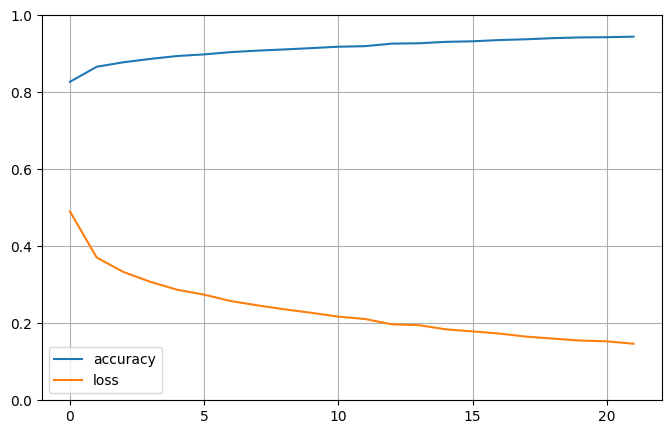

In [62]:
# wizualizujemy statystki dokładności naszej sieci neuronowej
pd.DataFrame(train_stats.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

In [63]:
# zapisujemy nasz wytrenowany model do pliku
f_mnist_model.save("fashion_mnist_model.keras")

In [64]:
# próbna predykcja sieci nieuronowej
y_pred = f_mnist_model.predict(X_test)
print("probs : ", y_pred[2])
print("klasa :", np.argmax(y_pred[2]))
print("rzeczywista klasa: ", y_test[2])

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
probs :  [1.3880377e-12 2.6234147e-11 3.1521484e-14 1.1464318e-16 1.7452231e-14
 2.7855397e-06 3.0855520e-12 9.9999720e-01 5.2222153e-13 3.4942321e-10]
klasa : 7
rzeczywista klasa:  7


In [65]:
# Nazwy klas
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


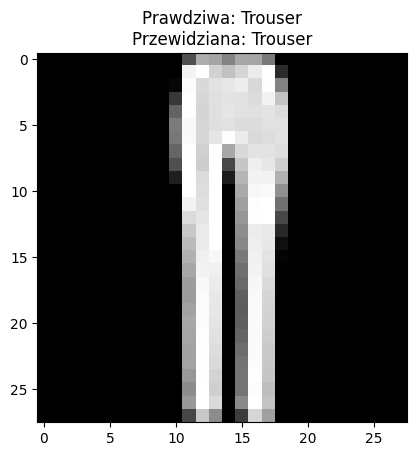

In [66]:
# ładujemy nasz model do zmiennej
f_mnist_model = load_model("fashion_mnist_model.keras")

# Interfejs: wybór przykładu, predykcja i rysowanie wybranego obrazka
def predict_and_show(index):
    if(index >= len(X_test)):
        raise ValueError("Indeks poza zakresem. Dozwolony zakres od 0 - 5999")
    image = X_test[index]
    label = y_test[index]

    image_input = np.expand_dims(image, axis=0)  # (1, 28, 28, 1)
    prediction = f_mnist_model.predict(image_input)
    predicted_label = np.argmax(prediction)

    # Wizualizacja
    plt.imshow(image.squeeze(), cmap='gray')
    plt.title(f"Prawdziwa: {class_names[label]}\nPrzewidziana: {class_names[predicted_label]}")
    plt.axis('on')
    plt.show()
    """
    	# define subplot
    plt.subplot(111)
    plt.title(f"Prawdziwa: {class_names[label]}\nPrzewidziana: {class_names[predicted_label]}")
    # plot raw pixel data
    plt.imshow(image, cmap=plt.get_cmap('gray'))
    # show the figure
    plt.show()
    """

# Przykład użycia interfejsu, zakres od 0 do 5999
predict_and_show(1)

In [67]:
# Augmentacje z Albumentations - augmentacja niestety nic nie dała w moim przypadku, wynik z augmentacja jest gorszy niż bez augmentacji
# poza tym to jest przykład zaczerpnięty z internetu i nie wszystko jeszcze rozumiem
"""
transform = A.Compose([
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.7),
    A.RandomBrightnessContrast(p=0.5),
    A.GaussianBlur(blur_limit=(3, 5), p=0.3),
    A.HorizontalFlip(p=0.5)
])
# Validation transforms - deterministic
val_transforms = A.Compose([
    A.Resize(28, 28),
    A.Normalize(mean=[0.1307], std=[0.3081]),
    A.ToTensorV2(),
])
"""
transform = A.Compose([
    A.Resize(32, 32),  # Slightly larger than target
    A.RandomCrop(28, 28),
    A.Rotate(limit=10, p=0.5),  # Small rotation
    A.Normalize(mean=[0.1307], std=[0.3081]),  # MNIST stats
    A.ToTensorV2(),
])
"""
transform = A.Compose([
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=10, p=0.7),
    A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.5),
    A.HorizontalFlip(p=0.5),
])
"""

'\ntransform = A.Compose([\n    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=10, p=0.7),\n    A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.5),\n    A.HorizontalFlip(p=0.5),\n])\n'

In [68]:
# Custom generator
class AugmentedDataGenerator(Sequence):
    def __init__(self, images, labels, batch_size=64, augment=True):
        self.images = images
        self.labels = labels
        self.batch_size = batch_size
        self.augment = augment
        self.indices = np.arange(len(images))

    def __len__(self):
        return int(np.ceil(len(self.images) / self.batch_size))

    def __getitem__(self, idx):
        batch_x = self.images[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_y = self.labels[idx * self.batch_size:(idx + 1) * self.batch_size]

        augmented_batch = []
        for img in batch_x:
            if self.augment:
                img = transform(image=img.squeeze())["image"]
                # Ensure the image has a channel dimension at the end after augmentation
                if img.ndim == 2:
                    img = np.expand_dims(img, -1)
            else:
                # Ensure non-augmented images also have a channel dimension at the end
                if img.ndim == 2:
                    img = np.expand_dims(img, -1)

            augmented_batch.append(img)

        # Transpose the batch to (batch_size, height, width, channels)
        augmented_batch = np.array(augmented_batch)
        # Check the shape and transpose if necessary
        if augmented_batch.shape[-1] != 1 and augmented_batch.shape[1] == 1:
             augmented_batch = np.transpose(augmented_batch, (0, 2, 3, 1))


        return augmented_batch, tf.keras.utils.to_categorical(batch_y, num_classes=10)

    def on_epoch_end(self):
        np.random.shuffle(self.indices)

In [69]:

"""
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])
"""
# Model CNN - model sieci neuronowej zaczerpnięty z internetu, niestety ten model niewiele pomógł przy uzsykaniu dokładności > 97
model = Sequential([
    Conv2D(64, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2),
    Dropout(0.25),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2),
    Dropout(0.25),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

# Kompilacja
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [70]:
# Generator danych
train_gen = AugmentedDataGenerator(X_train, y_train, augment=True)
val_gen = AugmentedDataGenerator(X_test, y_test, augment=False)

# Trenowanie
model.fit(train_gen, epochs=15, validation_data=val_gen)

Epoch 1/2


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 591ms/step - accuracy: 0.6706 - loss: 1.0240

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


844/844 ━━━━━━━━━━━━━━━━━━━━ 516s 606ms/step - accuracy: 0.6707 - loss: 1.0237 - val_accuracy: 0.1162 - val_loss: 59.6656
Epoch 2/2
844/844 ━━━━━━━━━━━━━━━━━━━━ 508s 602ms/step - accuracy: 0.7978 - loss: 0.5395 - val_accuracy: 0.1903 - val_loss: 32.5356


Podsumowując: udało mi się tego zadania uzyskać dokładność rzędu > 94 gdy użyłem 22 epok. Nie udało mi się uzyskać dla mojej sieci neuronowej dokładności > 97. Próbowałem jak umiałem: poprzez tranformację obrazków za pomocą metody compose i różne ustawienia modelu sieci neuronowej. Podejrzewam, że użyłem złych parametrów albo nie do końca optymalnych, chociaż jak widziałem w intern ecie niektórzy programiści uzyskiwali dla tego problemu dokładność rzędu około 0.85 więc nie byłem taki najgorszy.
